In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

Concatenate 9 datasets

In [4]:
#current work directory
path = os.getcwd()
#show all files
files = os.listdir(path)
files

['.git',
 '01_Washington.csv',
 '02_San_Diego.csv',
 '03_San_Francisco.csv',
 '04_Philadelphia.csv',
 '05_New_York.csv',
 '06_Miami.csv',
 '07_Las Vegas.csv',
 '08_Indianapolis.csv',
 '09_albuquerque.csv',
 'homestay.ipynb',
 'USA_Diff_States_webscraping']

In [9]:
file_needed = [
 '01_Washington.csv',
 '02_San_Diego.csv',
 '03_San_Francisco.csv',
 '04_Philadelphia.csv',
 '05_New_York.csv',
 '06_Miami.csv',
 '07_Las Vegas.csv',
 '08_Indianapolis.csv',
 '09_albuquerque.csv'
]

In [10]:
len(file_needed)

9

In [40]:
#initialized empty list
dfs = []

for f in file_needed:
    data = pd.read_csv(f)
    dfs.append(data)

#Combine all DataFrames
df_combined = pd.concat(dfs)
df_combined

,Unnamed: 0,visitor,Criteria,Homestay,Available_for,House_facilities,absolute_link
0,0,Meet Carmen,Response Rate85%,Urban Rustic,Welcomes Males Females Couples Families Students,Laundry Patio Barbecue TV Internet Access,https://www.homestay.com//united-states/washin...
1,1,Meet PAT,Garden,Urban Cosy,Welcomes Males Females Couples Families Students,Garden Laundry Barbecue TV Internet Access Smo...,https://www.homestay.com//united-states/washin...
2,2,Meet Mary,Response Rate100%,Urban Stylish,Welcomes Males Females Couples Families Students,Desk and Lamp Air Conditioning Dresser / Drawe...,https://www.homestay.com//united-states/falls-...
3,3,Meet Sri,Response Rate100%,Urban Cosy,Welcomes Males Females Couples Families Students,Laundry Parking Internet Access Air Conditioning,https://www.homestay.com//united-states/rockvi...
4,4,Meet Titik,Response Rate100%,Suburban Shabby chic,Welcomes Males Females Couples Families Students,Garden Games Room Laundry Patio Parking TV Int...,https://www.homestay.com//united-states/rockvi...
...,...,...,...,...,...,...,...
2,2,Meet Natasha,Garden,Urban Stylish,Welcomes Males Females Couples Families Students,Garden Bikes for use Laundry Parking Internet ...,https://www.homestay.com//united-states/albuqu...
3,3,Meet Michaela,Response Rate100%,Suburban Eco friendly,Welcomes Males Females Couples Families Students,Garden Bikes for use Laundry Patio Parking Int...,https://www.homestay.com//united-states/albuqu...
4,4,Meet John,Laundry,Suburban Stylish,Welcomes Males Females Couples Families Students,Laundry Parking Internet Access Air Conditioning,https://www.homestay.com//united-states/albuqu...
5,5,Meet Penelope,Laundry,Suburban Cosy,Welcomes Males Females Couples Families Students,Laundry Parking Internet Access Air Conditioning,https://www.homestay.com//united-states/albuqu...


Data Cleaning

In [47]:
#check for missing data
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 351 entries, 0 to 4
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        350 non-null    float64
 1   visitor           350 non-null    object 
 2   Criteria          350 non-null    object 
 3   Homestay          350 non-null    object 
 4   Available_for     350 non-null    object 
 5   House_facilities  350 non-null    object 
 6   absolute_link     350 non-null    object 
dtypes: float64(1), object(6)
memory usage: 30.0+ KB


In [46]:
#check for at least one missing value in row
df_combined[df_combined.isna().any(axis = 1)]

,Unnamed: 0,visitor,Criteria,Homestay,Available_for,House_facilities,absolute_link
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
#create missing value
df_combined.loc['4','Homestay'] = np.nan

In [52]:
df_combined = df_combined.dropna()


In [53]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 350 entries, 0 to 6
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        350 non-null    float64
 1   visitor           350 non-null    object 
 2   Criteria          350 non-null    object 
 3   Homestay          350 non-null    object 
 4   Available_for     350 non-null    object 
 5   House_facilities  350 non-null    object 
 6   absolute_link     350 non-null    object 
dtypes: float64(1), object(6)
memory usage: 21.9+ KB


In [54]:
df_combined

,Unnamed: 0,visitor,Criteria,Homestay,Available_for,House_facilities,absolute_link
0,0.0,Meet Carmen,Response Rate85%,Urban Rustic,Welcomes Males Females Couples Families Students,Laundry Patio Barbecue TV Internet Access,https://www.homestay.com//united-states/washin...
1,1.0,Meet PAT,Garden,Urban Cosy,Welcomes Males Females Couples Families Students,Garden Laundry Barbecue TV Internet Access Smo...,https://www.homestay.com//united-states/washin...
2,2.0,Meet Mary,Response Rate100%,Urban Stylish,Welcomes Males Females Couples Families Students,Desk and Lamp Air Conditioning Dresser / Drawe...,https://www.homestay.com//united-states/falls-...
3,3.0,Meet Sri,Response Rate100%,Urban Cosy,Welcomes Males Females Couples Families Students,Laundry Parking Internet Access Air Conditioning,https://www.homestay.com//united-states/rockvi...
4,4.0,Meet Titik,Response Rate100%,Suburban Shabby chic,Welcomes Males Females Couples Families Students,Garden Games Room Laundry Patio Parking TV Int...,https://www.homestay.com//united-states/rockvi...
...,...,...,...,...,...,...,...
2,2.0,Meet Natasha,Garden,Urban Stylish,Welcomes Males Females Couples Families Students,Garden Bikes for use Laundry Parking Internet ...,https://www.homestay.com//united-states/albuqu...
3,3.0,Meet Michaela,Response Rate100%,Suburban Eco friendly,Welcomes Males Females Couples Families Students,Garden Bikes for use Laundry Patio Parking Int...,https://www.homestay.com//united-states/albuqu...
4,4.0,Meet John,Laundry,Suburban Stylish,Welcomes Males Females Couples Families Students,Laundry Parking Internet Access Air Conditioning,https://www.homestay.com//united-states/albuqu...
5,5.0,Meet Penelope,Laundry,Suburban Cosy,Welcomes Males Females Couples Families Students,Laundry Parking Internet Access Air Conditioning,https://www.homestay.com//united-states/albuqu...


<Axes: >

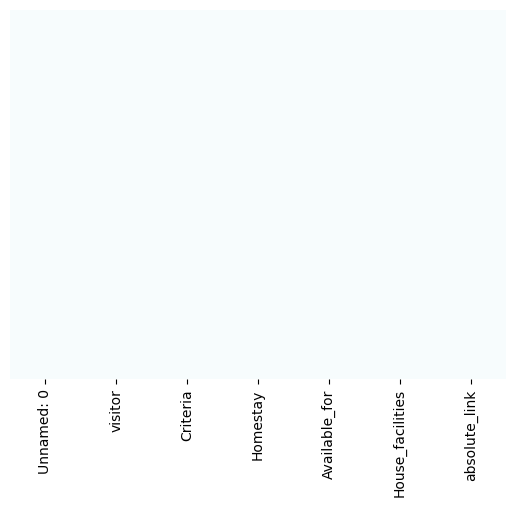

In [55]:
#check the missing value
sns.heatmap(df_combined.isna(),
            yticklabels=False,
            cbar=False,
            cmap='BuGn')

Reset/Change Index

In [56]:
df_combined = df_combined.reset_index(drop=True)
df_combined

,Unnamed: 0,visitor,Criteria,Homestay,Available_for,House_facilities,absolute_link
0,0.0,Meet Carmen,Response Rate85%,Urban Rustic,Welcomes Males Females Couples Families Students,Laundry Patio Barbecue TV Internet Access,https://www.homestay.com//united-states/washin...
1,1.0,Meet PAT,Garden,Urban Cosy,Welcomes Males Females Couples Families Students,Garden Laundry Barbecue TV Internet Access Smo...,https://www.homestay.com//united-states/washin...
2,2.0,Meet Mary,Response Rate100%,Urban Stylish,Welcomes Males Females Couples Families Students,Desk and Lamp Air Conditioning Dresser / Drawe...,https://www.homestay.com//united-states/falls-...
3,3.0,Meet Sri,Response Rate100%,Urban Cosy,Welcomes Males Females Couples Families Students,Laundry Parking Internet Access Air Conditioning,https://www.homestay.com//united-states/rockvi...
4,4.0,Meet Titik,Response Rate100%,Suburban Shabby chic,Welcomes Males Females Couples Families Students,Garden Games Room Laundry Patio Parking TV Int...,https://www.homestay.com//united-states/rockvi...
...,...,...,...,...,...,...,...
345,2.0,Meet Natasha,Garden,Urban Stylish,Welcomes Males Females Couples Families Students,Garden Bikes for use Laundry Parking Internet ...,https://www.homestay.com//united-states/albuqu...
346,3.0,Meet Michaela,Response Rate100%,Suburban Eco friendly,Welcomes Males Females Couples Families Students,Garden Bikes for use Laundry Patio Parking Int...,https://www.homestay.com//united-states/albuqu...
347,4.0,Meet John,Laundry,Suburban Stylish,Welcomes Males Females Couples Families Students,Laundry Parking Internet Access Air Conditioning,https://www.homestay.com//united-states/albuqu...
348,5.0,Meet Penelope,Laundry,Suburban Cosy,Welcomes Males Females Couples Families Students,Laundry Parking Internet Access Air Conditioning,https://www.homestay.com//united-states/albuqu...


#check for Outliers and doubles